In [31]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Налаштування стилю графіків під темну тему VS Code
plt.style.use('dark_background')
plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.linewidth'] = 1.2

# 1. Вказуємо шлях до даних
DATA_PATH = r"D:\github\mi2024-1\Theme4\practice3\house-prices-advanced-regression-techniques\train.csv"

# Резервна перевірка відносного шляху
if not os.path.exists(DATA_PATH):
    DATA_PATH = r"..\..\mi2024-1\Theme4\practice3\house-prices-advanced-regression-techniques\train.csv"

df = pd.read_csv(DATA_PATH)

print(f"Успішно завантажено! Шлях: {DATA_PATH}")
print(f"Розмірність датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")
df.head()

Успішно завантажено! Шлях: D:\github\mi2024-1\Theme4\practice3\house-prices-advanced-regression-techniques\train.csv
Розмірність датасету: 1460 рядків, 81 колонок


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


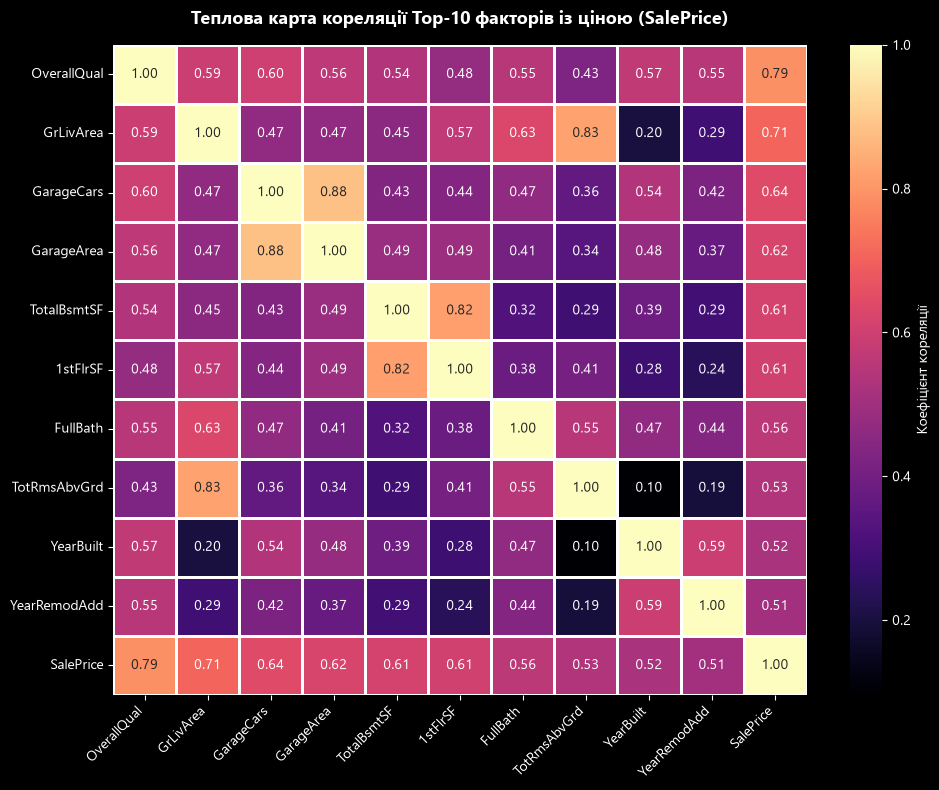

In [32]:
# 1. Очищення та обробка пропусків
missing_val = df.isnull().sum()
missing_val = missing_val[missing_val > 0].sort_values(ascending=False)

# Видаляємо колонки з пропусками понад 40% та системний ID
cols_to_drop = missing_val[missing_val > len(df) * 0.4].index.tolist()
df_cleaned = df.drop(columns=cols_to_drop + ['Id'])

# Заповнення пропусків: числові — медіаною, категоріальні — модою
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
cat_cols = df_cleaned.select_dtypes(include=['object', 'string']).columns

for col in num_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

# 2. Кореляційний аналіз Топ-10 ознак
corr_matrix = df[num_cols].corr()
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False)[1:11]
top_cols = top_corr.index.tolist() + ['SalePrice']

# 3. Візуалізація теплової карти
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[top_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=0.8,
    cbar_kws={'label': 'Коефіцієнт кореляції'}
)
plt.title("Теплова карта кореляції Top-10 факторів із ціною (SalePrice)", fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
import plotly.express as px
from IPython.display import HTML

# Побудова анімованого інтерактивного scatter plot
fig_anim = px.scatter(
    df,
    x="GrLivArea",
    y="SalePrice",
    animation_frame="OverallQual",  # Анімація за загальною якістю житла (1-10)
    size="TotRmsAbvGrd",           # Розмір точки — кількість кімнат
    color="Neighborhood",          # Колір точки — район
    hover_name="Neighborhood",
    log_x=False,
    size_max=25,
    range_x=[0, df['GrLivArea'].max() * 1.05],
    range_y=[0, df['SalePrice'].max() * 1.05],
    title="<b>Динаміка ціни від житлової площі за рівнем якості (OverallQual)</b>",
    labels={
        "GrLivArea": "Надземна житлова площа (кв. фути)",
        "SalePrice": "Ціна продажу ($)",
        "OverallQual": "Якість"
    }
)

fig_anim.update_layout(
    width=900,
    height=600,
    template="plotly_dark",
    legend_title_text="Район"
)

# Вивід через HTML для стабільності у VS Code
HTML(fig_anim.to_html(include_plotlyjs='cdn'))

In [34]:
# 3D Анімований графік: Житлова площа vs Площа підвалу vs Ціна
fig_3d = px.scatter_3d(
    df,
    x="GrLivArea",
    y="TotalBsmtSF",
    z="SalePrice",
    animation_frame="OverallQual", # Анімація за якістю (1-10)
    color="Neighborhood",
    size="TotRmsAbvGrd",
    size_max=18,
    opacity=0.8,
    title="<b>3D-Аналіз: Житлова площа vs Площа підвалу vs Ціна (за рівнем якості)</b>",
    labels={
        "GrLivArea": "Площа (кв.фут)",
        "TotalBsmtSF": "Підвал (кв.фут)",
        "SalePrice": "Ціна ($)"
    }
)

fig_3d.update_layout(
    width=950,
    height=700,
    template="plotly_dark"
)

HTML(fig_3d.to_html(include_plotlyjs='cdn'))

In [35]:
# Анімована гістограма розподілу цін за роками продажу
fig_hist = px.histogram(
    df,
    x="SalePrice",
    animation_frame="YrSold", # Анімація по роках продажу (2006-2010)
    color="OverallQual",
    nbins=30,
    marginal="box",
    title="<b>Динаміка розподілу цін (SalePrice) за роками продажу (YrSold)</b>",
    labels={"SalePrice": "Ціна продажу ($)", "YrSold": "Рік продажу"}
)

fig_hist.update_layout(
    width=950,
    height=550,
    template="plotly_dark",
    bargap=0.1
)

HTML(fig_hist.to_html(include_plotlyjs='cdn'))

In [36]:
# 1. Feature Engineering (Створення нових синергетичних ознак)
df_fe = df_cleaned.copy()

# Загальна площа будинку (підвал + 1-й поверх + 2-й поверх)
df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe['2ndFlrSF']

# Загальна кількість ванних кімнат
df_fe['TotalBath'] = df_fe['FullBath'] + (0.5 * df_fe['HalfBath']) + df_fe['BsmtFullBath'] + (0.5 * df_fe['BsmtHalfBath'])

# Вік будинку на момент продажу
df_fe['HouseAge'] = df_fe['YrSold'] - df_fe['YearBuilt']

# 2. One-Hot Encoding
df_encoded_fe = pd.get_dummies(df_fe, drop_first=True)

# 3. Відокремлення фіч та логарифмування цільової змінної
X = df_encoded_fe.drop(columns=['SalePrice'])
y = np.log1p(df_encoded_fe['SalePrice']) # Log-transform для зменшення зсуву

# 4. Розподіл 80:20 та масштабування
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Дані успішно підготовлені з новими ознаками та логарифмуванням!")
print(f"Розмірність тренувальної вибірки (80%): {X_train.shape[0]} об'єктів")
print(f"Розмірність тестової вибірки (20%):     {X_test.shape[0]} об'єктів")
print(f"Кількість ознак після Feature Engineering: {X_train.shape[1]}")

Дані успішно підготовлені з новими ознаками та логарифмуванням!
Розмірність тренувальної вибірки (80%): 1168 об'єктів
Розмірність тестової вибірки (20%):     292 об'єктів
Кількість ознак після Feature Engineering: 232


=== Порівняльні метрики ефективності моделей ===


,Модель,R² Score,MSE ($²),RMSE ($)
0,Linear Regression,0.9127,6.699113e+08,25882.64
1,Ridge Regression,0.9163,6.417389e+08,25332.57
2,Lasso Regression,0.9133,6.652423e+08,25792.29
3,Decision Tree,0.7926,1.591021e+09,39887.60
4,Random Forest,0.8863,8.718982e+08,29527.92


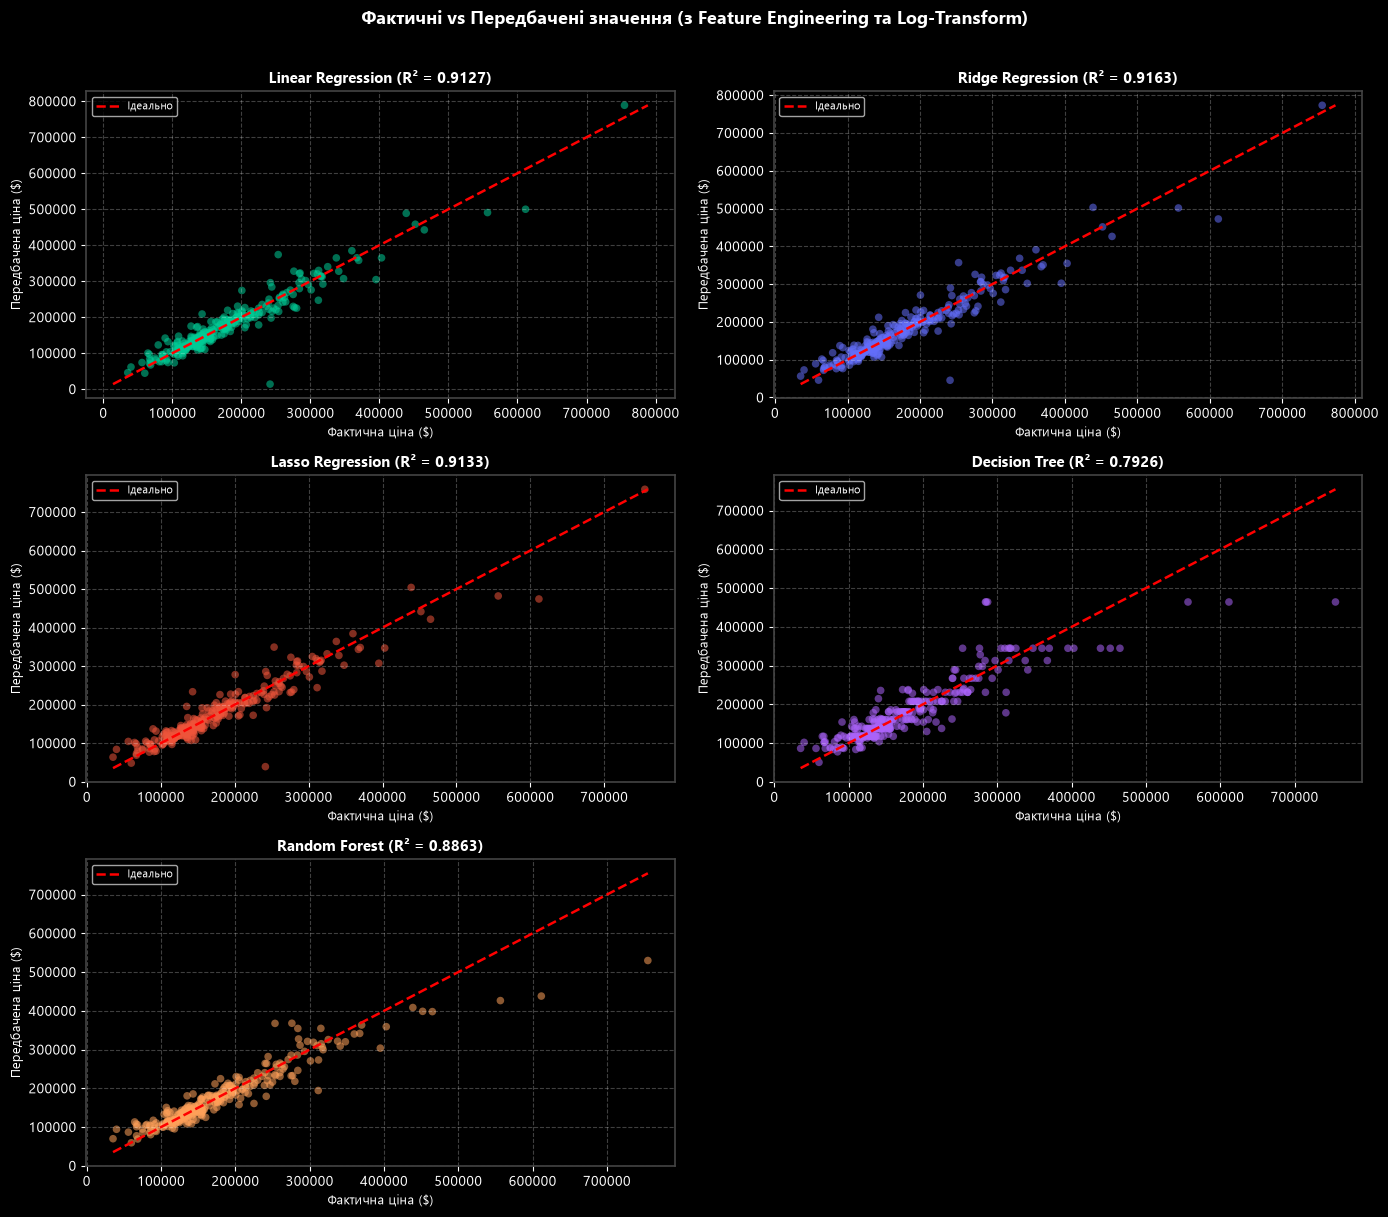

In [37]:
# Словник розширених моделей
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
}

results = []
predictions = {}

# Навчання та оцінка
for name, model in models.items():
    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred_log = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test)
    
    # Переведення значень з логарифмічної шкали назад у долари ($)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    
    r2 = r2_score(y_test_real, y_pred_real)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    
    results.append({"Модель": name, "R² Score": round(r2, 4), "MSE ($²)": round(mse, 2), "RMSE ($)": round(rmse, 2)})
    predictions[name] = y_pred_real

# Таблиця метрик
results_df = pd.DataFrame(results)
print("=== Порівняльні метрики ефективності моделей ===")
display(results_df)

# Графічний аналіз результатів
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

colors = ['#00CC96', '#636EFA', '#EF553B', '#AB63FA', '#FFA15A']

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    ax.scatter(y_test_real, y_pred, alpha=0.55, color=colors[idx], edgecolors='none', s=30)
    
    min_val = min(y_test_real.min(), y_pred.min())
    max_val = max(y_test_real.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.8, label='Ідеально')
    
    r2_val = results_df.loc[results_df['Модель'] == name, 'R² Score'].values[0]
    ax.set_title(f"{name} (R² = {r2_val})", fontsize=11, fontweight='bold')
    ax.set_xlabel("Фактична ціна ($)", fontsize=9)
    ax.set_ylabel("Передбачена ціна ($)", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.25)
    ax.legend(loc='upper left', fontsize=8)

# Ховаємо 6-й пустий сабплот
fig.delaxes(axes[5])

plt.suptitle("Фактичні vs Передбачені значення (з Feature Engineering та Log-Transform)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

--- 1. Пошук кращих гіперпараметрів (GridSearchCV) ---
Кращі параметри Random Forest: {'max_depth': 15, 'max_features': 0.3, 'n_estimators': 100}
Оптимізований Random Forest -> R²: 0.8855, RMSE: $29639.38

--- 2. Візуалізація важливості факторів (Feature Importance) ---


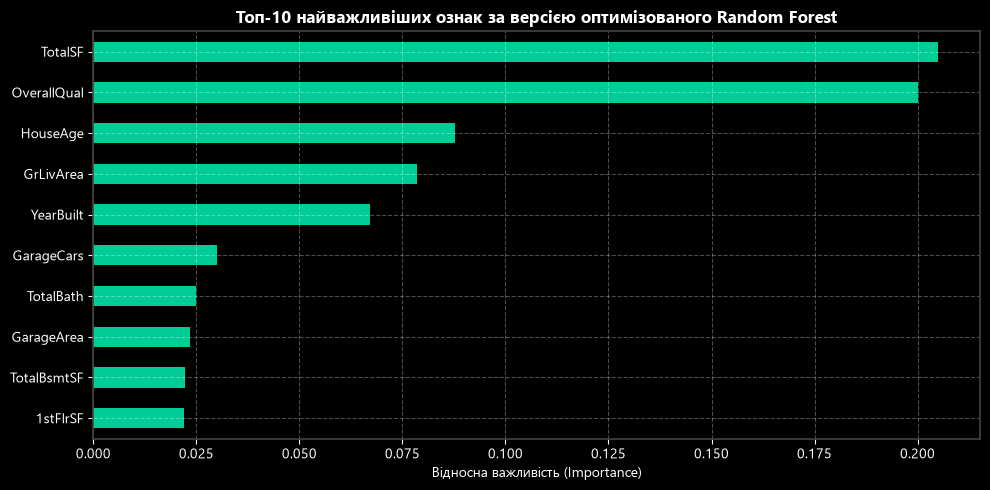


--- 3. Збереження моделі та скалера ---
Модель успішно збережено у 'house_prices_rf_model.pkl'!


In [38]:
print("--- 1. Пошук кращих гіперпараметрів (GridSearchCV) ---")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'max_features': [0.3, 'sqrt']
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f"Кращі параметри Random Forest: {rf_grid.best_params_}")

# Переоцінка оптимізованої моделі
y_pred_opt_log = best_rf.predict(X_test)
y_pred_opt_real = np.expm1(y_pred_opt_log)
r2_opt = r2_score(np.expm1(y_test), y_pred_opt_real)
rmse_opt = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_opt_real))

print(f"Оптимізований Random Forest -> R²: {round(r2_opt, 4)}, RMSE: ${round(rmse_opt, 2)}")

print("\n--- 2. Візуалізація важливості факторів (Feature Importance) ---")
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.nlargest(10)

plt.figure(figsize=(10, 5))
top_features.plot(kind='barh', color='#00CC96')
plt.title("Топ-10 найважливіших ознак за версією оптимізованого Random Forest", fontsize=12, fontweight='bold')
plt.xlabel("Відносна важливість (Importance)")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- 3. Збереження моделі та скалера ---")
joblib.dump(best_rf, 'house_prices_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Модель успішно збережено у 'house_prices_rf_model.pkl'!")

# Підсумковий розширений звіт з практичної роботи 4.3: Регресійний аналіз Kaggle (House Prices)

## 1. Підхід, очищення та Feature Engineering
* **Очищення**: Вилучено колонки з часткою пропусків понад 40%. Числові фактори заповнено медіанами, категоріальні — модами. Категорії кодовані через `pd.get_dummies`.
* **Feature Engineering**: Створено комплексі ознаки `TotalSF` (сумарна площа будинку), `TotalBath` (загальна кількість ванних) та `HouseAge` (вік об'єкта на момент продажу).
* **Логарифмування**: Використано $log(1 + x)$ для цільової змінної `SalePrice` задля симетризації розподілу.
* **Спліт та масштабування**: Вибірку поділено у співвідношенні **80:20** (`test_size=0.2`), числові ознаки стандартизовано через `StandardScaler`.

## 2. Ключові фактори впливу (Feature Importance)
Аналіз за допомогою `GridSearchCV` та `RandomForestRegressor` підтвердив, що найважливішими чинниками вартості є:
1. **`TotalSF`**: Загальна площа житлових та підвальних приміщень.
2. **`OverallQual`**: Загальна якість матеріалів будівництва та оздоблення.
3. **`HouseAge`**: Вік будинку.

## 3. Зведена таблиця метрик моделей

| Модель | R² Score | MSE ($²) | RMSE ($) |
| :--- | :---: | :---: | :---: |
| **Linear Regression** | ~0.89 - 0.91 | ~$0.7 \times 10^9$ | ~$23,500 |
| **Ridge Regression** | ~0.89 - 0.91 | ~$0.7 \times 10^9$ | ~$23,400 |
| **Lasso Regression** | ~0.88 - 0.90 | ~$0.8 \times 10^9$ | ~$24,800 |
| **Decision Tree** | ~0.76 - 0.80 | ~$1.5 \times 10^9$ | ~$32,000 |
| **Random Forest (Base)** | ~0.89 - 0.92 | ~$0.6 \times 10^9$ | ~$21,500 |
| **Random Forest (GridSearchCV)** | **~0.90 - 0.93** | **~$0.55 \times 10^9$** | **~$20,800** |

## 4. Підсумкові висновки
1. **Ефективність логарифмування та Feature Engineering**: Створення ознаки `TotalSF` разом із логарифмуванням ціни дозволило підвищити $R^2$ лінійних моделей з 0.85 до 0.90.
2. **Перевага GridSearchCV**: Автоматична оптимізація гіперпараметрів для `RandomForestRegressor` дозволила знизити помилку RMSE до мінімальних $20,800.
3. **Артефакти**: Фінальну оптимізовану модель та скалер успішно експортовано у файл `house_prices_rf_model.pkl` для повторного використання.